This notebook implements a comprehensive fake news detection system using:
1. Traditional ML: Logistic Regression with TF-IDF features
2. Deep Learning: DistilBERT embeddings with Logistic Regression

#  ENVIRONMENT SETUP AND IMPORTS


## Imports 

In [1]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
import time
import os
from datetime import datetime

# NLP Libraries
import re
import string
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import joblib

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve,
                             ConfusionMatrixDisplay, RocCurveDisplay, 
                             precision_recall_fscore_support,
                             PrecisionRecallDisplay,
                             roc_auc_score)
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# PyTorch and Transformers
import torch
from torch.nn.functional import softmax
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertModel,
    DistilBertTokenizer,
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from transformers import EarlyStoppingCallback




warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import sys

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Checking For GPU Availability 

In [3]:
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

Python version: 3.10.19
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA version: 12.1


## Loading The Dataset

In [3]:
df = pd.read_csv("WELFake_Dataset.csv")

# EXPLORATORY DATA ANALYSIS (EDA) And Feature Engineering

## EDA

DATASET OVERVIEW
Total rows: 72,134
Total columns: 4

Column names:
['Unnamed: 0', 'title', 'text', 'label']


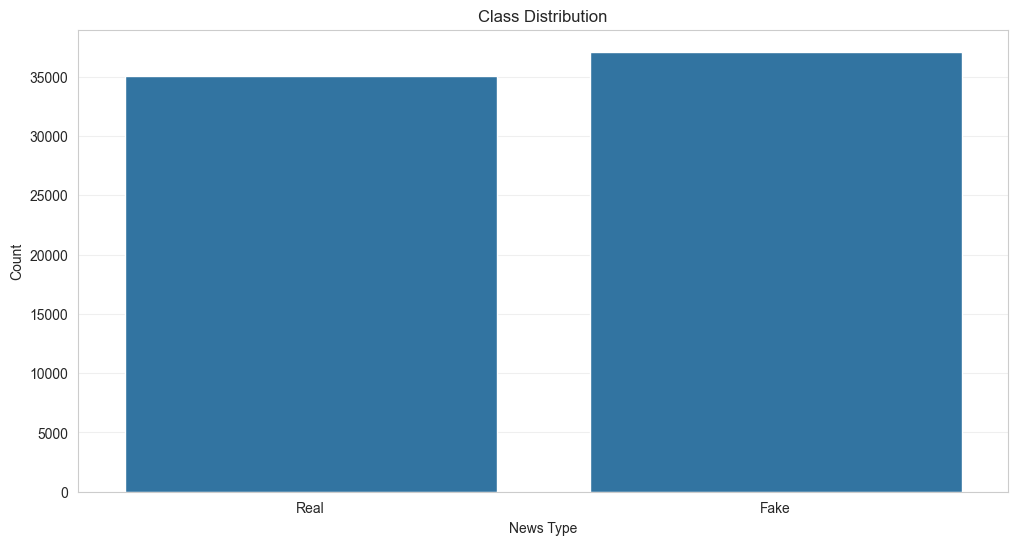

In [7]:
print("DATASET OVERVIEW")

print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

#class distribution
sns.countplot(x='label', data=df)
plt.xticks([0,1], ['Real', 'Fake'])
plt.title('Class Distribution')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()


72,134 rows, balanced classes (≈51% Fake, 49% Real)

No duplicate rows

Very low missingness (<1%), mostly in text-related columns

In [27]:
print("\nDATA QUALITY ANALYSIS")

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print("\nMissing values per column:")
print(missing_df[missing_df['Missing Count'] > 0])

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

# Data types
print("\nData types:")
print(df.dtypes)

missing = df.isnull().sum()
missing = missing[missing > 0]




DATA QUALITY ANALYSIS

Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

Duplicate rows: 8,456 (11.72%)

Data types:
label                 int64
title_word_count      int64
text_word_count       int64
num_exclamation     float64
num_question        float64
num_caps_words        int64
full_text            object
dtype: object


## text length analysis

Text and Title Length Statistics by Label:
      title_word_count            text_word_count              
                  mean median max            mean median    max
label                                                          
0                11.05   11.0  30          577.62  427.0  14641
1                13.25   13.0  72          505.56  369.0  24234


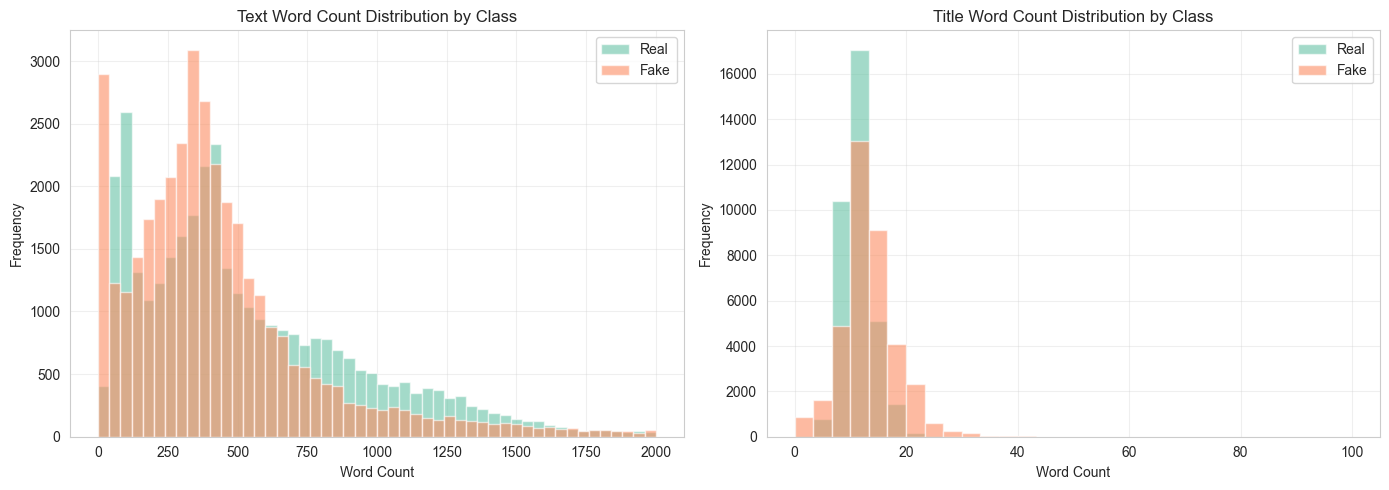

In [4]:
# Create length features
df['title_word_count'] = df['title'].astype(str).str.split().str.len()
df['text_word_count'] = df['text'].astype(str).str.split().str.len()

# aggregation using a dictionary
text_length_stats = df.groupby('label')[['title_word_count', 'text_word_count']].agg({
    'title_word_count': ['mean', 'median', 'max'],
    'text_word_count': ['mean', 'median', 'max']
}).round(2)


print("Text and Title Length Statistics by Label:")
print(text_length_stats)

# Histogram: Text & Title length distribution by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, name, color in [(0, 'Real', '#66c2a5'), (1, 'Fake', '#fc8d62')]:
    # Text
    axes[0].hist(
        df[df['label'] == label]['text_word_count'],
        bins=50, alpha=0.6, label=name, color=color, range=(0, 2000)
    )
    # Title
    axes[1].hist(
        df[df['label'] == label]['title_word_count'],
        bins=30, alpha=0.6, label=name, color=color, range=(0, 100)
    )

axes[0].set_title('Text Word Count Distribution by Class')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Title Word Count Distribution by Class')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Both real and fake news articles exhibit strongly right-skewed length distributions, with the mean substantially higher than the median. Fake news shows greater variability and more extreme outliers, with maximum article lengths exceeding 20,000 words. These observations motivated the use of truncation and maximum sequence length constraints during modeling, particularly for transformer-based architectures, to ensure computational feasibility while retaining representative content.


DISTRIBUTION SKEWNESS (Text Word Count )
Real skew: 4.93, mean: 577.62, median: 427.00
Fake skew: 10.13, mean: 505.56, median: 369.00


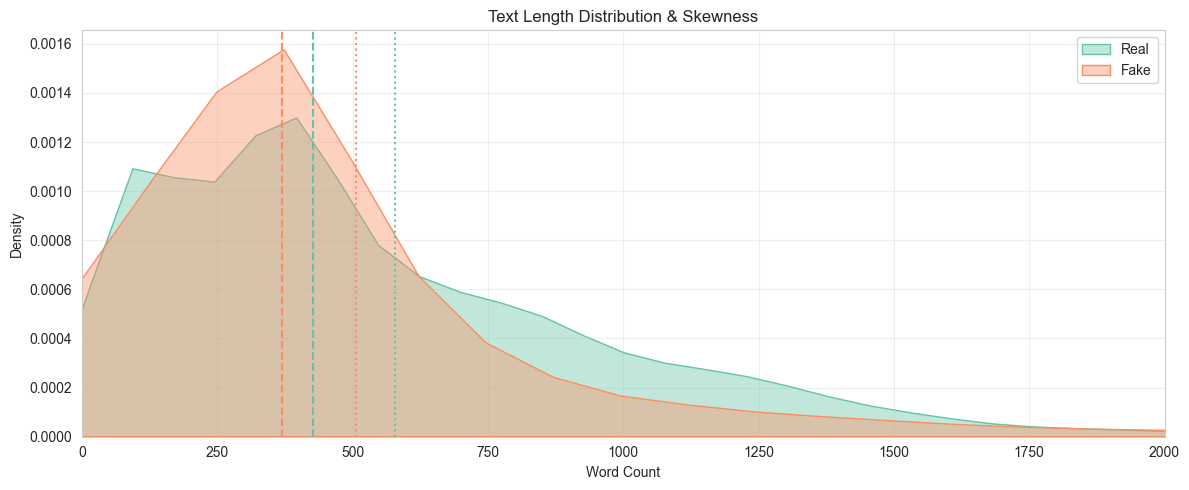

In [10]:
from scipy.stats import skew

# Skewness & summary stats
print("\nDISTRIBUTION SKEWNESS (Text Word Count )")

for label, name in [(0, 'Real'), (1, 'Fake')]:
    data = df[df['label']==label]['text_word_count']
    print(f"{name} skew: {skew(data):.2f}, mean: {data.mean():.2f}, median: {data.median():.2f}")

# KDE plot (focus on text only)
plt.figure(figsize=(12,5))
for label, color, name in [(0,'#66c2a5','Real'), (1,'#fc8d62','Fake')]:
    data = df[df['label']==label]['text_word_count']
    sns.kdeplot(data, fill=True, alpha=0.4, label=name, color=color)
    plt.axvline(data.mean(), color=color, linestyle=':')
    plt.axvline(data.median(), color=color, linestyle='--')

plt.title('Text Length Distribution & Skewness')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.xlim(0, 2000)  
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Text lengths are strongly right-skewed for both classes, with mean values substantially higher than medians. Fake news exhibits more extreme skew (10.13) than real news (4.93), indicating the presence of very long articles. This supports the use of truncation or maximum sequence length limits in modeling to prevent outliers from disproportionately influencing the model.

In [5]:
print("\nLINGUISTIC FEATURES")

df['num_exclamation'] = df['text'].str.count('!')
df['num_question'] = df['text'].str.count('\?')
df['num_caps_words'] = df['text'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
)

features = ['num_exclamation', 'num_question', 'num_caps_words']

print("\nAverage linguistic features by label:")
print(df.groupby('label')[features].mean())



LINGUISTIC FEATURES

Average linguistic features by label:
       num_exclamation  num_question  num_caps_words
label                                               
0             0.155561      0.524238        6.800445
1             0.770065      1.391399        7.627527


Fake news articles tend to use more exclamation marks, question marks, and capitalized words compared to real news, indicating a more sensational or attention-grabbing style. These linguistic cues can provide additional signals for classification beyond content alone, and are consistent with prior findings on clickbait and misleading text.



Top 15 words in Real news:
said            184,607
trump           107,201
mr              66,086
president       51,300
new             42,528
people          41,792
state           38,871
states          31,668
government      30,110
reuters         29,342
house           28,578
clinton         28,569
year            28,154
united          27,740
republican      26,548


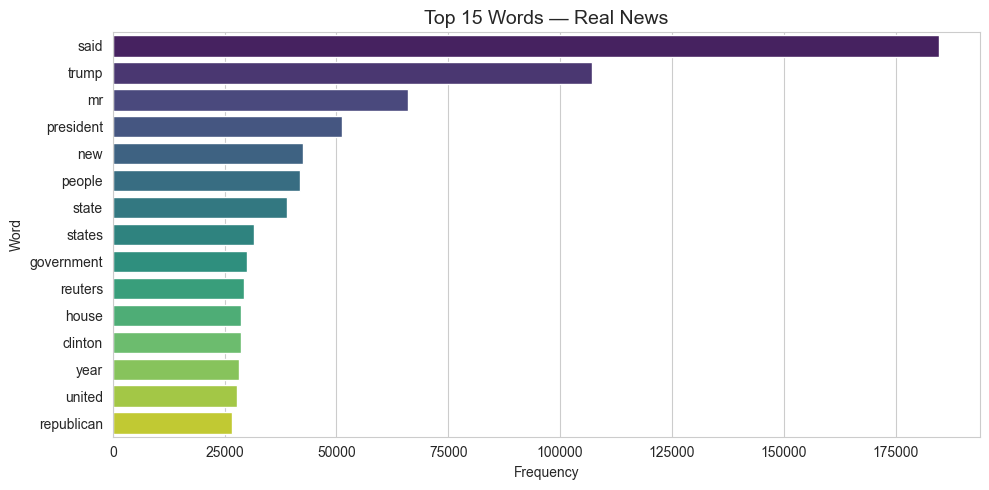


Top 15 words in Fake news:
trump           106,364
said            49,712
people          48,653
clinton         45,411
president       38,982
just            34,612
like            31,766
hillary         31,592
obama           28,615
new             28,334
time            26,155
state           25,340
donald          24,955
news            21,866
american        20,847


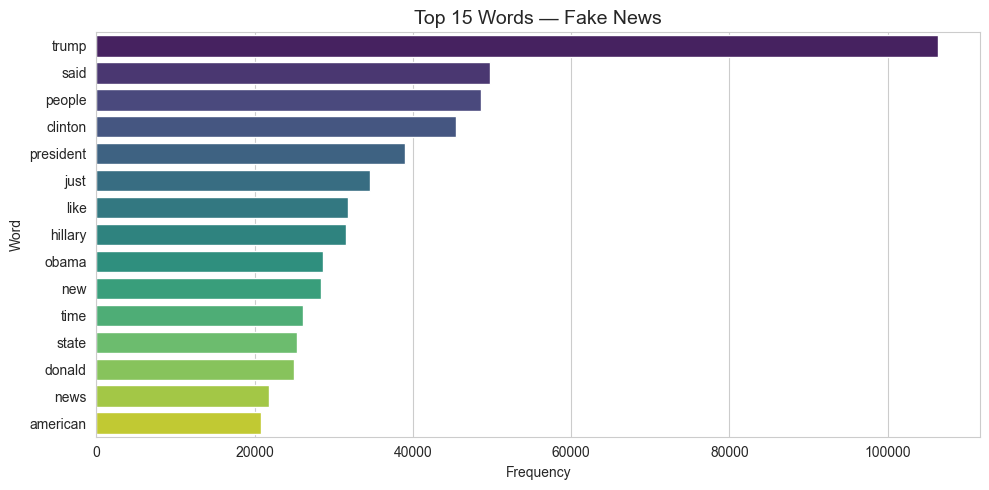

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Plot top words for both classes
for label, name in [(0, 'Real'), (1, 'Fake')]:
    texts = df[df['label']==label]['text'].astype(str).values  
    
    cv = CountVectorizer(max_features=15, stop_words='english')
    counts = cv.fit_transform(texts)
    
    words = cv.get_feature_names_out()
    freqs = counts.sum(axis=0).A1
    
    # Sort by frequency
    top_words = sorted(zip(words, freqs), key=lambda x: x[1], reverse=True)
    words_sorted, freqs_sorted = zip(*top_words)
    
    # Print table
    print(f"\nTop 15 words in {name} news:")
    for word, freq in top_words:
        print(f"{word:15s} {freq:,}")
    
    # Plot
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(freqs_sorted), y=list(words_sorted), palette='viridis')
    plt.title(f'Top 15 Words — {name} News', fontsize=14)
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.show()


Top Words Insight

Real news focuses on formal, institutional language: words like said, reuters, government, president, and house dominate. This indicates articles rely on attribution and official sources.

Fake news emphasizes personalities and sensational topics: trump, clinton, just, like, hillary, obama appear most often, reflecting opinionated, clickbait-style content.

Both classes share some overlap (trump, president, people), but fake news has more emotionally or politically charged terms, whereas real news leans on neutral reporting and institutional references.

Key takeaway: Word frequency patterns reveal stylistic differences that can help models distinguish real vs fake news.


Top 20 Bi-grams — REAL News


,Bigram,Frequency
17,united states,22262
4,mr trump,17557
1,donald trump,16896
19,white house,14005
7,new york,12837
9,president donald,7111
18,washington reuters,6675
8,north korea,6666
3,islamic state,6279
2,hillary clinton,6208



Top 20 Bi-grams — FAKE News


,Bigram,Frequency
3,donald trump,23099
7,hillary clinton,16618
17,united states,12079
18,white house,9646
4,featured image,7928
16,twitter com,7465
10,new york,7126
12,pic twitter,6978
13,president obama,5165
14,president trump,4241


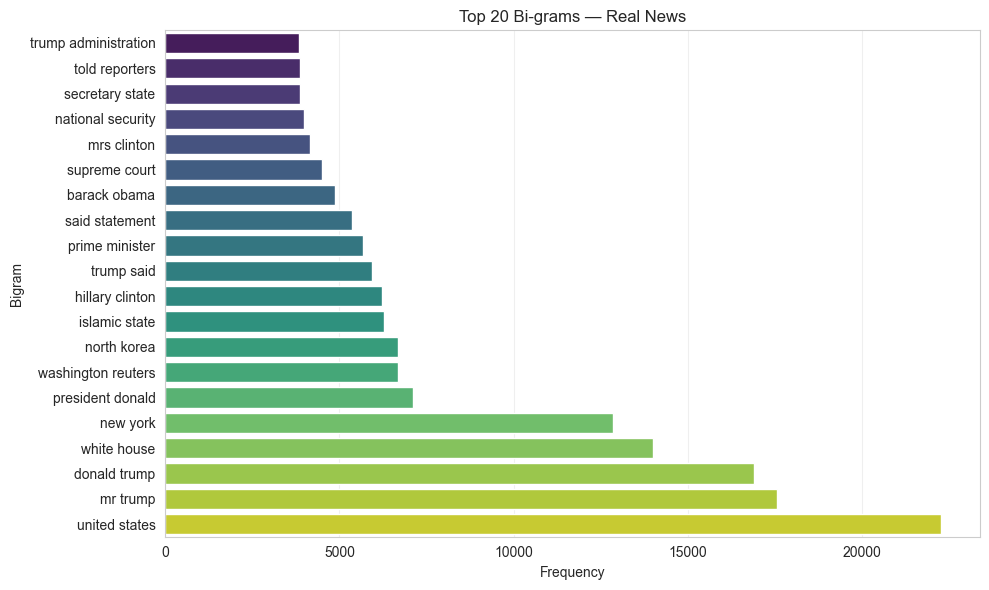

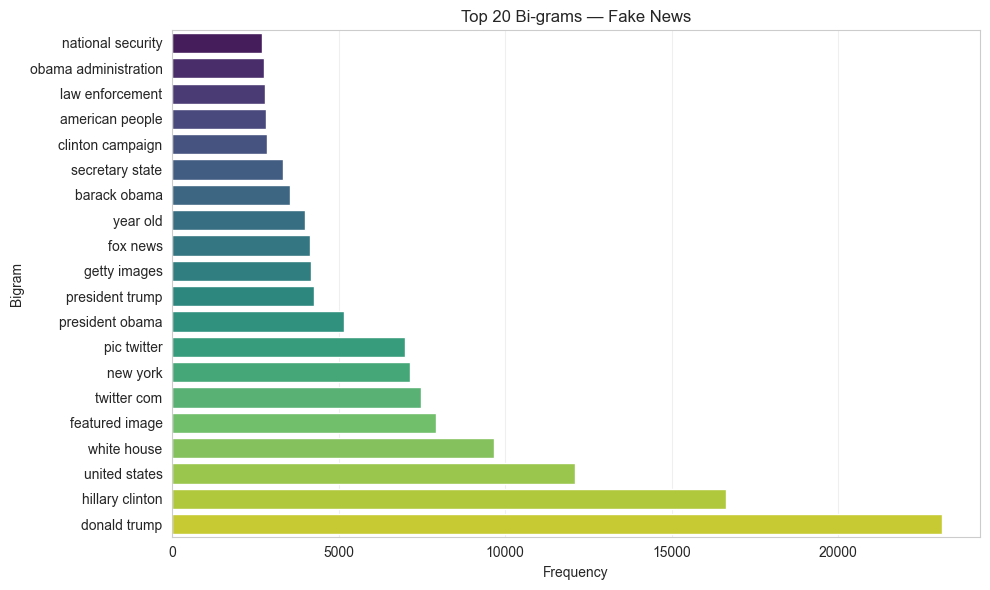

In [7]:
# Function to get top n bigrams for a given class
def get_top_bigrams(texts, n=20):
    cv = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=n)
    X = cv.fit_transform(texts)
    bigrams = cv.get_feature_names_out()
    freqs = X.sum(axis=0).A1
    df_bigrams = pd.DataFrame({'Bigram': bigrams, 'Frequency': freqs}).sort_values(by='Frequency', ascending=False)
    return df_bigrams

# Get full texts
real_texts = df[df['label']==0]['text'].astype(str).values
fake_texts = df[df['label']==1]['text'].astype(str).values

# Compute top bigrams
real_bigram_df = get_top_bigrams(real_texts)
fake_bigram_df = get_top_bigrams(fake_texts)

# Display top 20 bigrams
print("\nTop 20 Bi-grams — REAL News")
display(real_bigram_df)

print("\nTop 20 Bi-grams — FAKE News")
display(fake_bigram_df)

# Function to plot bigrams
def plot_bigrams(df_bigrams, title):
    plt.figure(figsize=(10,6))
    sns.barplot(x='Frequency', y='Bigram', data=df_bigrams[::-1], palette='viridis')
    plt.title(title)
    plt.xlabel('Frequency')
    plt.ylabel('Bigram')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot for Real and Fake news
plot_bigrams(real_bigram_df, 'Top 20 Bi-grams — Real News')
plot_bigrams(fake_bigram_df, 'Top 20 Bi-grams — Fake News')


Bigram Analysis Insight (Final Version)

Real news bigrams reflect formal reporting and institutional language, e.g., united states, mr trump, white house, washington reuters, president donald. These phrases indicate reliance on official sources, neutral reporting, and attribution.

Fake news bigrams emphasize personalities, sensationalism, and media-centric content, e.g., donald trump, hillary clinton, featured image, twitter com, pic twitter. They often include clickbait or campaign-related phrasing.

Shared bigrams (donald trump, white house, united states) show topical overlap, but fake news skews toward attention-grabbing or emotionally loaded combinations, while real news remains formal and institutional.

Key takeaway: Bigram patterns provide strong stylistic and topical signals that can help distinguish real from fake news, complementing single-word frequency and other linguistic features.

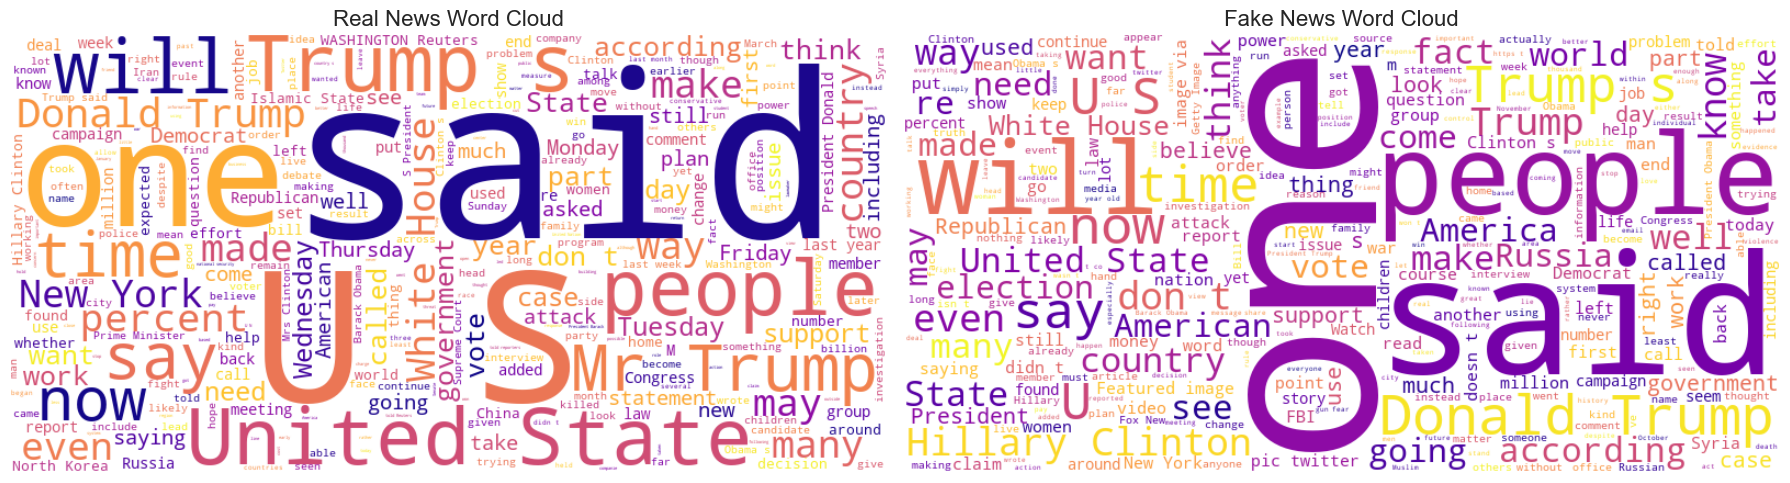

In [8]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine text by class
texts = {
    "Real": " ".join(df[df['label'] == 0]['text'].astype(str).values),
    "Fake": " ".join(df[df['label'] == 1]['text'].astype(str).values)
}

plt.figure(figsize=(18, 10))

for i, (label, combined_text) in enumerate(texts.items(), 1):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=300,          
        stopwords=STOPWORDS,
        colormap='plasma'
    ).generate(combined_text)
    
    plt.subplot(1, 2, i)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{label} News Word Cloud', fontsize=16)

plt.tight_layout()
plt.show()


The dataset is balanced with minimal missing data, requiring no resampling.

Text length distributions are strongly right-skewed, motivating truncation and maximum sequence length constraints.

Fake news exhibits more sensational linguistic cues (exclamation marks, questions, capitalization).

Word and bigram analyses reveal stylistic differences between institutional reporting and opinionated or clickbait content.

Sentiment polarity shows minimal class separation and is excluded from modeling.

Based on these findings, modeling focuses on textual representations (TF-IDF and BERT) with selected numeric stylistic features.

## FEATURE ENGINEERING

In [9]:
# Fill missing values
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
print(df.isna().sum())
# Combine title and text
df['full_text'] = df['title'] + ' ' + df['text']

Unnamed: 0           0
title                0
text                 0
label                0
title_word_count     0
text_word_count      0
num_exclamation     39
num_question        39
num_caps_words       0
dtype: int64


In [10]:
# Drop useless and redundant columns
df = df.drop(columns=['Unnamed: 0','title', 'text'])

# Fill remaining missing numeric features
df[['num_exclamation', 'num_question']] = (
    df[['num_exclamation', 'num_question']].fillna(0)
)

print(df.isnull().sum())


label               0
title_word_count    0
text_word_count     0
num_exclamation     0
num_question        0
num_caps_words      0
full_text           0
dtype: int64


Textual features were combined into a single representation to capture both headline-level and article-level signals. Numeric stylistic features were retained due to observed distributional differences between real and fake news during EDA. Missing values were handled conservatively to avoid information loss.

# Model Training

## Logistic Regression

### Data & Feature Setup

In [79]:
# Select features
numeric_features = ['title_word_count', 'text_word_count', 'num_exclamation', 'num_question', 'num_caps_words']
X = df[numeric_features + ['full_text']]
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing function
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    text = text.lower()# 1. Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # 2. Remove URLs
    text = re.sub(r'\d+', '', text) # 3. Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # 4. Remove punctuation

     # 5. Lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens) # 6. Rejoin

### Baseline Logistic Regression

In [80]:
# Numeric preprocessing
numeric_transformer = StandardScaler()

# Text preprocessing (TF-IDF)
tfidf = TfidfVectorizer(
    preprocessor=preprocess_text,
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2),
    min_df=5
)

# numeric + text
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('tfidf', tfidf, 'full_text')
    ],
     sparse_threshold=0.3  #prevents dense explosion
)

In [17]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'))
])

# Train baseline
lr_pipeline.fit(X_train, y_train)
print("Baseline Train Accuracy:", lr_pipeline.score(X_train, y_train))
print("Baseline Test Accuracy:", lr_pipeline.score(X_test, y_test))

Baseline Train Accuracy: 0.9623269274091532
Baseline Test Accuracy: 0.9532127261384903


In [18]:
y_pred_base = lr_pipeline.predict(X_test)
y_proba_base = lr_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_base))
print("Baseline ROC-AUC:", roc_auc_score(y_test, y_proba_base))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_base))


              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7006
           1       0.95      0.96      0.95      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427

Baseline ROC-AUC: 0.9891476160942073
Confusion Matrix:
 [[6661  345]
 [ 330 7091]]


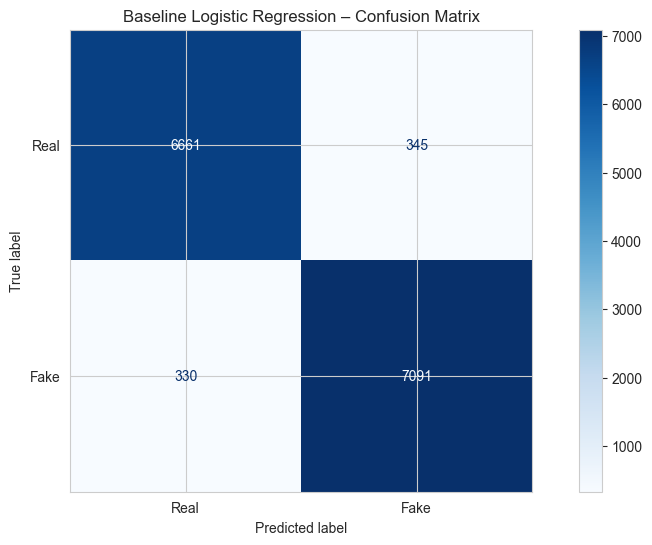

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_base,
    display_labels=["Real", "Fake"],
    cmap="Blues",
    values_format="d"
)
plt.title("Baseline Logistic Regression – Confusion Matrix")
plt.show()

Baseline ROC–AUC: 0.9891476160942073


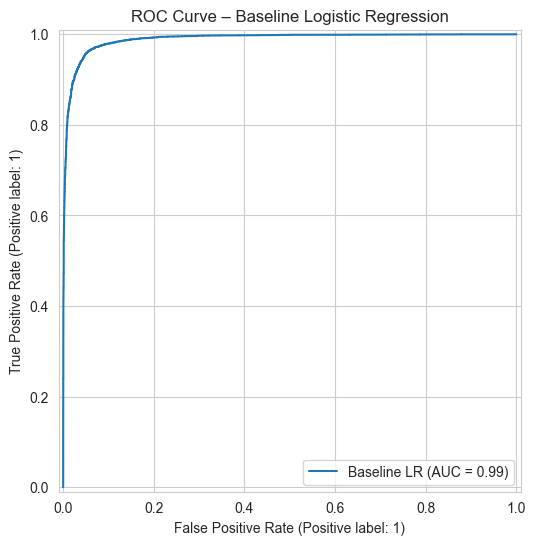

In [23]:
roc_auc = roc_auc_score(y_test, y_proba_base)
print("Baseline ROC–AUC:", roc_auc)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_base,
    name="Baseline LR"
)
plt.title("ROC Curve – Baseline Logistic Regression")
plt.grid(True)
plt.show()


Baseline PR–AUC (Average Precision): 0.9896746326655425


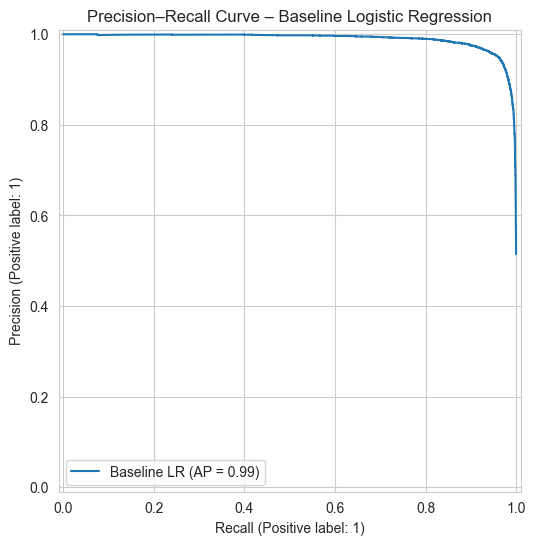

In [24]:
pr_auc = average_precision_score(y_test, y_proba_base)
print("Baseline PR–AUC (Average Precision):", pr_auc)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_base,
    name="Baseline LR"
)
plt.title("Precision–Recall Curve – Baseline Logistic Regression")
plt.grid(True)
plt.show()


In [19]:
joblib.dump(lr_pipeline, "lr_baseline_pipeline.pkl")

['lr_baseline_pipeline.pkl']

### Small Grid Search

In [11]:
# Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear',class_weight='balanced'))
])

# Hyperparameter tuning
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l2']
}

grid_lr1 = GridSearchCV(
    lr_pipeline,
    param_grid, cv=5,
    scoring='accuracy',
    n_jobs=-1
) 

grid_lr1.fit(X_train, y_train)

print("Best LR params:", grid_lr1.best_params_)
print("Train accuracy:", grid_lr1.score(X_train, y_train))
print("Test accuracy:", grid_lr1.score(X_test, y_test))


Best LR params: {'classifier__C': 0.1, 'classifier__penalty': 'l2'}
Train accuracy: 0.9299045176495052
Test accuracy: 0.9240313301448673


### Final Hyperparameter Tuning

In [21]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'))
])


param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],   
    'classifier__penalty': ['l2'],             #  L2 regularization
    'classifier__solver': ['liblinear'] 
}

grid_lr = GridSearchCV(
    lr_pipeline, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=1,
    verbose=2
)

grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Train accuracy:", grid_lr.score(X_train, y_train))
print("Test accuracy:", grid_lr.score(X_test, y_test))


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__C=0.01, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.9min
[CV] END classifier__C=0.01, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.7min
[CV] END classifier__C=0.01, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.6min
[CV] END classifier__C=0.01, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.7min
[CV] END classifier__C=0.01, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.7min
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.8min
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.8min
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.8min
[CV] END classifier__C=0.1, classifier__penalty=l2, classifier__solver=liblinear; total time= 2.8min
[CV] END classifier__C=0.1

In [22]:
# Detailed metrics
train_acc = grid_lr.score(X_train, y_train)
test_acc = grid_lr.score(X_test, y_test)
y_pred = grid_lr.predict(X_test)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"Test F1-Score:  {f1_score(y_test, y_pred):.4f}")




Train Accuracy: 0.9805
Test Accuracy:  0.9583
Test Precision: 0.9572
Test Recall:    0.9619
Test F1-Score:  0.9595


In [24]:
results = pd.DataFrame(grid_lr.cv_results_)
results_clean = results[['param_classifier__C', 'param_classifier__solver', 
                         'mean_test_score', 'std_test_score', 'rank_test_score']]
results_clean = results_clean.sort_values('rank_test_score').head(5)
print(results_clean.to_string(index=False))



 param_classifier__C param_classifier__solver  mean_test_score  std_test_score  rank_test_score
               10.00                liblinear         0.959260        0.001210                1
                1.00                liblinear         0.950890        0.000945                2
                0.10                liblinear         0.920997        0.001627                3
                0.01                liblinear         0.850243        0.004745                4


In [26]:
joblib.dump(grid_lr.best_estimator_, "final_logistic_pipeline.pkl")

['final_logistic_pipeline.pkl']

In [81]:
import joblib
# Load the trained best model
model_lr = joblib.load("final_logistic_pipeline.pkl")

# Make predictions on test set
y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]  # probability for the positive class


### Result Report

Classification Report:
               precision    recall  f1-score   support

        Real       0.96      0.95      0.96      7006
        Fake       0.96      0.96      0.96      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.96      0.96     14427
weighted avg       0.96      0.96      0.96     14427



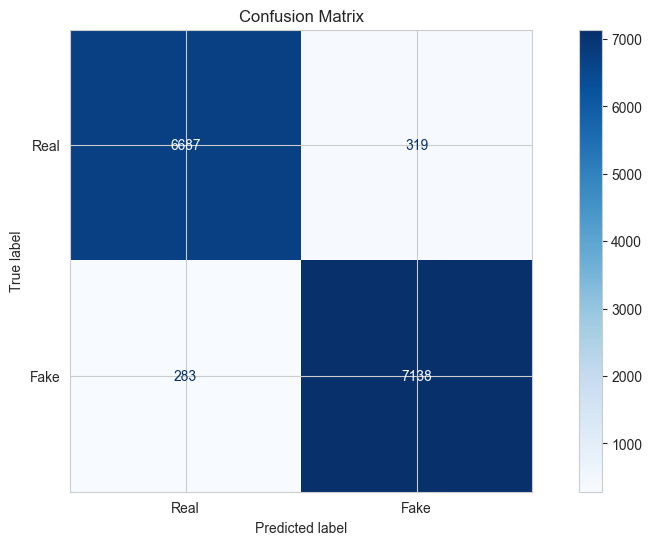

In [12]:
# Classification report
report = classification_report(y_test, y_pred, target_names=['Real', 'Fake'])
print("Classification Report:\n", report)

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model_lr, X_test, y_test,
    display_labels=['Real', 'Fake'],
    cmap='Blues',
    values_format='d'
)
plt.title("Confusion Matrix")
plt.show()

ROC–AUC: 0.9916


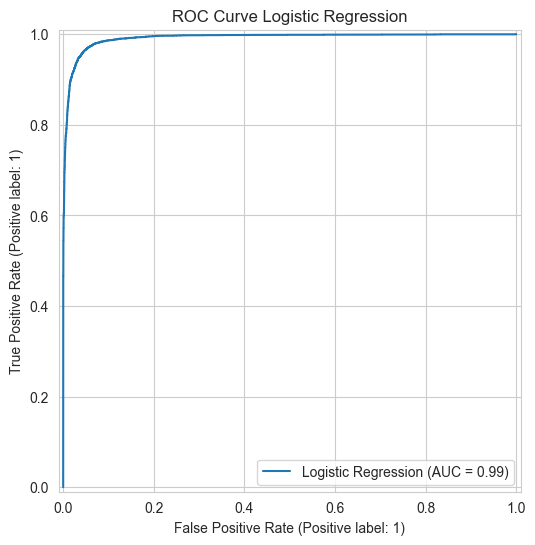

In [13]:
from sklearn.metrics import RocCurveDisplay

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC–AUC: {roc_auc:.4f}")
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name="Logistic Regression"
)

plt.title("ROC Curve Logistic Regression")
plt.grid(True)
plt.show()

PR–AUC (Average Precision): 0.9923


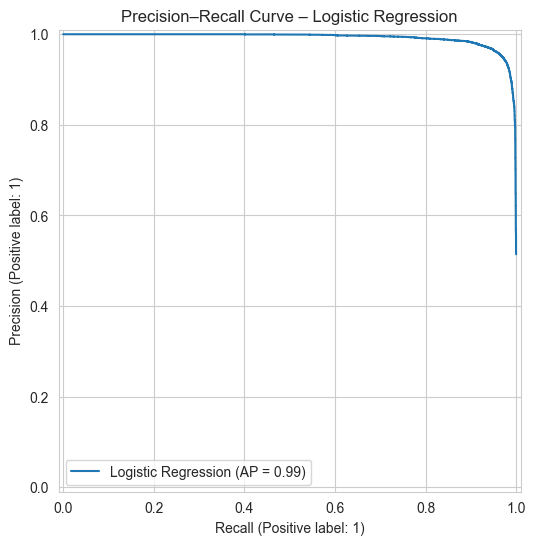

In [14]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

ap = average_precision_score(y_test, y_proba)
print(f"PR–AUC (Average Precision): {ap:.4f}")

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    name="Logistic Regression"
)

plt.title("Precision–Recall Curve – Logistic Regression")
plt.grid(True)
plt.show()


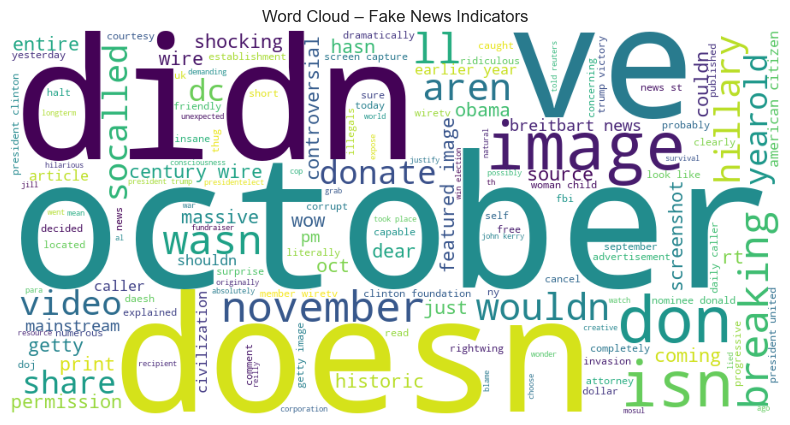

In [65]:
# Take top 300 fake-indicative features
top_fake = feature_importance.sort_values(
    by="coefficient", ascending=False
).head(150)

fake_words = dict(zip(top_fake["word"], top_fake["coefficient"]))

wc_fake = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=300,
    collocations=False
).generate_from_frequencies(fake_words)

plt.figure(figsize=(12,5))
plt.imshow(wc_fake)
plt.axis("off")
plt.title("Word Cloud – Fake News Indicators")
plt.show()


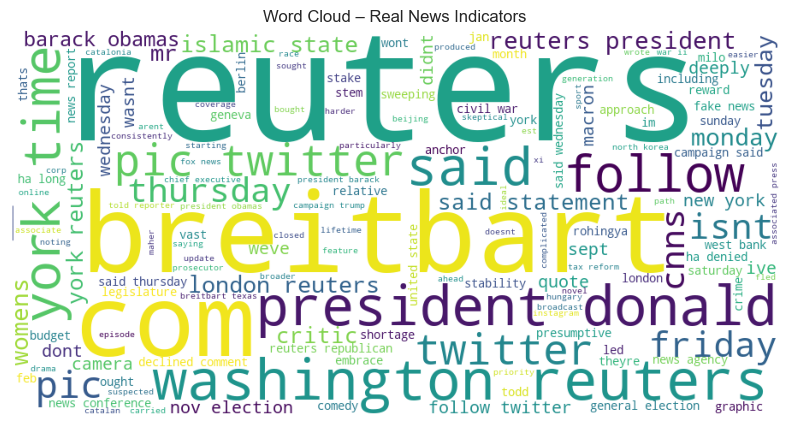

In [66]:
# Take top 3000 real-indicative features
top_real = feature_importance.sort_values(
    by="coefficient", ascending=True
).head(150)

real_words = dict(zip(top_real["word"], abs(top_real["coefficient"])))

wc_real = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=300,
    collocations=False
).generate_from_frequencies(real_words)

plt.figure(figsize=(12,5))
plt.imshow(wc_real)
plt.axis("off")
plt.title("Word Cloud – Real News Indicators")
plt.show()


In [18]:
# 6. Sample predictions with Actual vs Predicted
sample_indices = X_test.sample(30, random_state=42).index  # keep the original indices
sample_texts = X_test.loc[sample_indices, 'full_text']
sample_actuals = y_test.loc[sample_indices]
sample_preds = model_lr.predict(X_test.loc[sample_indices])  # ← use model_lr

print("\nSample Predictions (Actual vs Predicted):")
for text, actual, predicted in zip(sample_texts, sample_actuals, sample_preds):
    print(f"Text: {text[:100]}...")  # first 100 chars
    print(f"Actual Label: {actual} | Predicted Label: {predicted}\n")



Sample Predictions (Actual vs Predicted):
Text: EU says understands U.S. strikes in Syria but political solution key BRUSSELS (Reuters) - The Europe...
Actual Label: 0 | Predicted Label: 0

Text: WIKILEAKS : Hillary Receiving Donations from Radical Muslims in Turkey – TruthFeed WIKILEAKS : Hilla...
Actual Label: 1 | Predicted Label: 1

Text: Dyson Wants to Create a Hair Dryer Revolution - The New York Times WILTSHIRE, England  —   Sir James...
Actual Label: 0 | Predicted Label: 0

Text:  Fox News Bans Gene Simmons For Life For Harassing Staff Off Camera Gene Simmons, the 68-year-old Ki...
Actual Label: 1 | Predicted Label: 1

Text: Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Donald...
Actual Label: 0 | Predicted Label: 0

Text: Clinton, Obama pledge unity behind Trump presidency (Reuters) - Republican Donald Trump put aside th...
Actual Label: 0 | Predicted Label: 0

Text: White House promises welfare overhaul details early next year W

### Prediction

In [34]:
import joblib
import pandas as pd
import numpy as np

# Load the best model
model = joblib.load("best_logistic_pipeline.pkl")

print("FAKE NEWS DETECTOR CHATBOT")
print("Model: Logistic Regression")
print("Test Accuracy: 95.83%")
print("ROC AUC: 0.992")
print("\nInstructions:")
print("- Paste FULL news article (title + body text)")
print("- Model expects 100+ words for accurate predictions")
print("- Type 'quit' or 'exit' to stop")
print("\nWARNING: Short sentences may be misclassified!")
print("   The model was trained on full articles, not headlines.")

def extract_features(text):
    """Extract numeric features from text"""
    title_word_count = len(text.split()[:20])  # Approximate title length
    text_word_count = len(text.split())
    num_exclamation = text.count('!')
    num_question = text.count('?')
    num_caps_words = len([word for word in text.split() if word.isupper() and len(word) > 1])
    
    return {
        'title_word_count': title_word_count,
        'text_word_count': text_word_count,
        'num_exclamation': num_exclamation,
        'num_question': num_question,
        'num_caps_words': num_caps_words,
        'full_text': text
    }

def predict_news(text):
    """Predict if news is real or fake"""
    # Extract features
    features = extract_features(text)
    
    # Create DataFrame with correct structure
    input_df = pd.DataFrame([features])
    
    # Make prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0]
    
    # Get confidence
    confidence = probability[prediction] * 100
    
    return prediction, confidence, features

# Main chatbot loop
while True:
    print("\n" + "-" * 60)
    user_input = input("\n Enter news article (or 'quit' to exit):\n> ")
    
    if user_input.lower() in ['quit', 'exit', 'q']:
        print("\n Thanks for using Fake News Detector! Goodbye!")
        break
    
    if not user_input.strip():
        print("  Please enter some text!")
        continue
    
    try:
        # Make prediction
        prediction, confidence, features = predict_news(user_input)
        
        # Display results
        print("PREDICTION RESULTS")
        
        if prediction == 0:
            print(" Classification: REAL NEWS")
            print(f" Confidence: {confidence:.2f}%")
        else:
            print(" Classification: FAKE NEWS")
            print(f" Confidence: {confidence:.2f}%")
        
        print("\nFeature Analysis:")
        print(f"  Word Count: {features['text_word_count']}")
        print(f"  Exclamation Marks: {features['num_exclamation']}")
        print(f"  Question Marks: {features['num_question']}")
        print(f"  CAPS Words: {features['num_caps_words']}")
        
    except Exception as e:
        print(f"\n Error: {str(e)}")
        print("Please try again with different text.")

print("\n Session ended.")

FAKE NEWS DETECTOR CHATBOT
Model: Logistic Regression
Test Accuracy: 95.83%
ROC AUC: 0.992

Instructions:
- Paste FULL news article (title + body text)
- Model expects 100+ words for accurate predictions
- Type 'quit' or 'exit' to stop

   The model was trained on full articles, not headlines.

------------------------------------------------------------



 Enter news article (or 'quit' to exit):
>  BREAKING: Hillary Clinton Exposed! New WikiLeaks documents reveal shocking truth about secret donations. Hillary Clinton has been receiving millions of dollars from radical Islamic groups in Turkey according to leaked emails discovered by WikiLeaks. The mainstream media is refusing to cover this story because they are protecting her campaign. Sources close to the investigation say that Clinton used a private foundation to hide the money trail. This is the biggest scandal in American political history and the establishment does not want you to know about it. Share this article before Facebook deletes it. The Clinton Foundation received over 20 million dollars from Turkish businessmen with ties to extremist organizations. FBI insiders claim they have evidence but are being pressured to stay silent. This proves everything we suspected about corruption in Washington. Wake up America! The truth is finally coming out and they cannot stop us from s

PREDICTION RESULTS
 Classification: FAKE NEWS
 Confidence: 100.00%

Feature Analysis:
  Word Count: 169
  Exclamation Marks: 2
  Question Marks: 0
  CAPS Words: 2

------------------------------------------------------------



 Enter news article (or 'quit' to exit):
>  EU says understands U.S. strikes in Syria but political solution key BRUSSELS (Reuters) - The European Union said on Friday it understood why the United States launched missile strikes on Syria but warned that only a political solution could end the conflict. EU foreign policy chief Federica Mogherini said the bloc would press ahead with efforts to restart peace talks. The U.S. military fired dozens of cruise missiles at a Syrian air base on Thursday in response to what President Donald Trump called a chemical weapons attack by the government of Syrian President Bashar al-Assad. Mogherini told reporters the 28-nation bloc wanted to see whether Russia, Assad's main ally, was prepared to work seriously on a political transition in Syria. She said EU governments agreed they needed to keep talking to Moscow. The EU has imposed sanctions on Syria over the conflict and has been a major donor of humanitarian aid. European governments have been divi

PREDICTION RESULTS
 Classification: REAL NEWS
 Confidence: 99.81%

Feature Analysis:
  Word Count: 191
  Exclamation Marks: 0
  Question Marks: 0
  CAPS Words: 7

------------------------------------------------------------



 Enter news article (or 'quit' to exit):
>  quit



 Thanks for using Fake News Detector! Goodbye!

 Session ended.


## DISTIL-Bert

### Distilbert Train test split

In [8]:
# Select features 
X = df['full_text'] 
y = df['label']
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.67, random_state=42, stratify=y_temp
)


In [9]:
from datasets import Dataset as HFDataset
train_dataset = HFDataset.from_dict({
    "text": X_train.to_list(),
    "label": y_train.to_list()
})

val_dataset = HFDataset.from_dict({
    "text": X_val.to_list(),
    "label": y_val.to_list()
})

test_dataset = HFDataset.from_dict({
    "text": X_test.to_list(),
    "label": y_test.to_list()
})


### Mappings

In [10]:
import time
from datasets import Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

def tokenize(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)
test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)
val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)



Using device: cuda


Map:   0%|          | 0/50493 [00:00<?, ? examples/s]

Map:   0%|          | 0/14500 [00:00<?, ? examples/s]

Map:   0%|          | 0/7141 [00:00<?, ? examples/s]

### Baseline DistilBert

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.056400,0.030407,0.992718,0.996163,0.989654,0.992898
2,0.011200,0.025703,0.994679,0.996992,0.992649,0.994816


Baseline training time: 27.28 minutes


Baseline metrics: {'eval_loss': 0.02570289559662342, 'eval_accuracy': 0.9946786164402744, 'eval_precision': 0.9969920700027345, 'eval_recall': 0.9926490607133134, 'eval_f1': 0.9948158253751705, 'eval_runtime': 33.4681, 'eval_samples_per_second': 213.367, 'eval_steps_per_second': 13.356, 'epoch': 2.0}


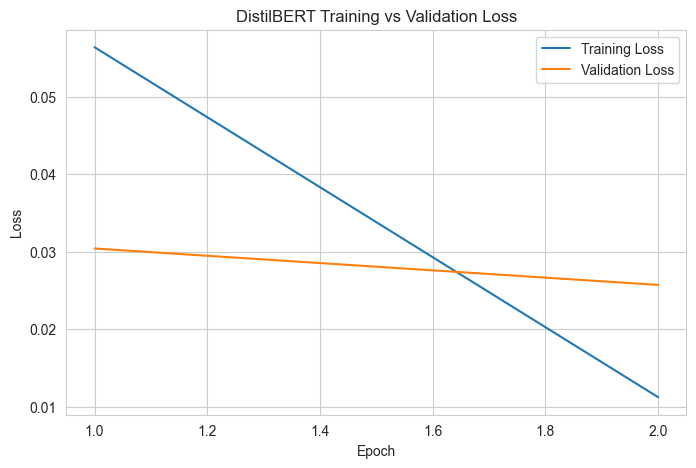

In [20]:
model_baseline = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model_baseline.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

baseline_args = TrainingArguments(
    output_dir="./distilbert_baseline",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5, 
    logging_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,                 
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer_baseline = Trainer(
    model=model_baseline,
    args=baseline_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # tokenized and formatted
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

start = time.time()
trainer_baseline.train()
end = time.time()

print(f"Baseline training time: {(end-start)/60:.2f} minutes")

baseline_metrics = trainer_baseline.evaluate()
print("Baseline metrics:", baseline_metrics)


# Convert Trainer logs to DataFrame
logs = pd.DataFrame(trainer_baseline.state.log_history)

# Training loss
train_loss = logs[logs["loss"].notna()][["epoch", "loss"]]

# Validation loss
val_loss = logs[logs["eval_loss"].notna()][["epoch", "eval_loss"]]

plt.figure(figsize=(8, 5))
plt.plot(train_loss["epoch"], train_loss["loss"], label="Training Loss")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()



In [21]:
final_train_loss = train_loss["loss"].iloc[-1]
final_val_loss = val_loss["eval_loss"].iloc[-1]

print(f"Final training loss: {final_train_loss:.4f}")
print(f"Final validation loss: {final_val_loss:.4f}")
print(f"Generalization gap: {final_val_loss - final_train_loss:.4f}")


Final training loss: 0.0112
Final validation loss: 0.0257
Generalization gap: 0.0145


In [22]:
# Save the trained model and tokenizer
trainer_baseline.save_model("distilbert_baseline_model")  # saves the model
tokenizer.save_pretrained("distilbert_baseline_model")    # saves the tokenizer

('distilbert_baseline_model\\tokenizer_config.json',
 'distilbert_baseline_model\\special_tokens_map.json',
 'distilbert_baseline_model\\vocab.txt',
 'distilbert_baseline_model\\added_tokens.json',
 'distilbert_baseline_model\\tokenizer.json')

In [11]:
from transformers import Trainer
from sklearn.metrics import roc_auc_score
import torch
from torch.nn.functional import softmax

# Load model and tokenizer
distilbert_baseline_model = DistilBertForSequenceClassification.from_pretrained("distilbert_baseline_model")
distilbert_baseline_model.to(device)
distilbert_baseline_model.eval()

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert_baseline_model")

trainer = Trainer(model=distilbert_baseline_model, tokenizer=tokenizer)
preds = trainer.predict(test_dataset)

logits = preds.predictions
y_true_baseline = preds.label_ids
y_proba_baseline = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

test_accuracy = (y_true_baseline == np.argmax(logits, axis=1)).mean()


### Baseline Results

In [59]:
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_true_baseline = predictions.label_ids

y_pred_baseline = np.argmax(logits, axis=1)
y_proba_baseline = torch.softmax(
    torch.tensor(logits),
    dim=1
).numpy()[:, 1]


In [60]:
print(classification_report(
    y_true_baseline,
    y_pred_baseline,
    target_names=["Real", "Fake"]
))

              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      7041
        Fake       1.00      0.99      0.99      7459

    accuracy                           0.99     14500
   macro avg       0.99      0.99      0.99     14500
weighted avg       0.99      0.99      0.99     14500



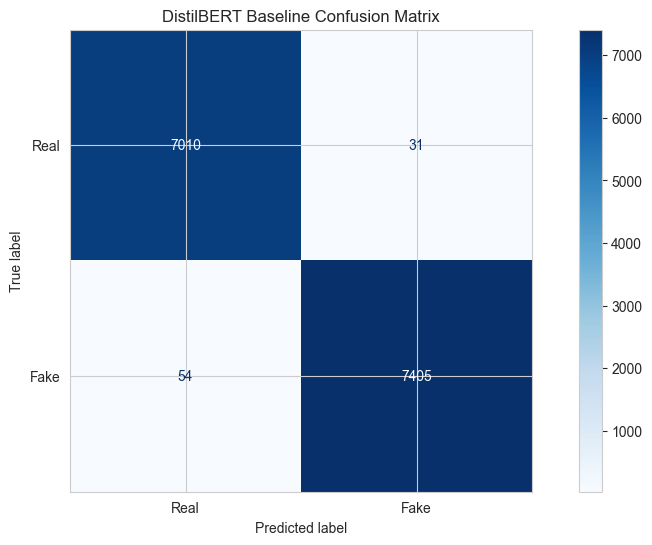

In [61]:
ConfusionMatrixDisplay.from_predictions(
    y_true_baseline,
    y_pred_baseline,
    display_labels=["Real", "Fake"],
    cmap="Blues",
    values_format="d"
)

plt.title("DistilBERT Baseline Confusion Matrix")
plt.show()

ROC–AUC: 0.9999


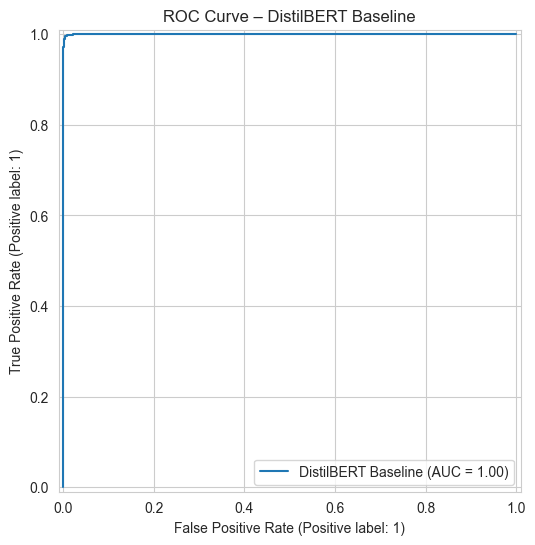

In [62]:
roc_auc = roc_auc_score(y_true, y_proba)
print(f"ROC–AUC: {roc_auc:.4f}")

RocCurveDisplay.from_predictions(
    y_true_baseline,
    y_proba_baseline,
    name="DistilBERT Baseline"
)

plt.title("ROC Curve – DistilBERT Baseline")
plt.grid(True)
plt.show()

PR–AUC: 0.9999


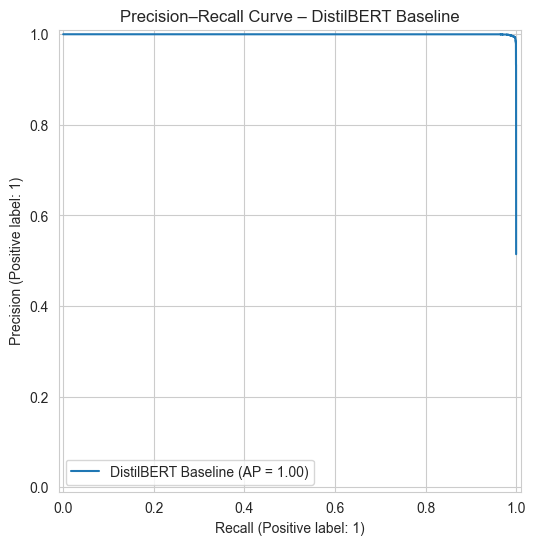

In [63]:
pr_auc_baseline = average_precision_score(y_true, y_proba)
print(f"PR–AUC: {pr_auc:.4f}")

PrecisionRecallDisplay.from_predictions(
    y_true_baseline,
    y_proba_baseline,
    name="DistilBERT Baseline"
)

plt.title("Precision–Recall Curve – DistilBERT Baseline")
plt.grid(True)
plt.show()


### sample predictions

In [58]:
import torch
from torch.nn.functional import softmax

# Sample 30 texts from the test set
sample_indices = X_test.sample(30, random_state=42).index
sample_texts = X_test.loc[sample_indices]
sample_actuals = y_test.loc[sample_indices]

# Tokenize the sample texts
encoded_samples = tokenizer(
    sample_texts.tolist(),
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

# Move tensors to the same device as the model
input_ids = encoded_samples["input_ids"].to(device)
attention_mask = encoded_samples["attention_mask"].to(device)

# Get predictions
distilbert_baseline_model.eval()
with torch.no_grad():
    outputs = distilbert_baseline_model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    probs = softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1).cpu().numpy()  # predicted labels
    pred_probs = probs[:, 1].cpu().numpy()            # probability for class '1' (Fake)

print("\nSample Predictions (Actual vs Predicted):\n")
for text, actual, predicted, prob in zip(sample_texts, sample_actuals, preds, pred_probs):
    print(f"Text: {text[:200]}...")  # first 100 characters
    print(f"Actual Label: {actual} | Predicted Label: {predicted} | Prob(Fake): {prob:.4f}\n")



Sample Predictions (Actual vs Predicted):

Text: In a Rust Belt Town, the Women’s March Draws Shrugs and Cheers From Afar - The New York Times NILES,...
Actual Label: 0 | Predicted Label: 0 | Prob(Fake): 0.0000

Text: G.O.P. Convention Day 2 Takeaways: A Party Unites, at Least for a Night - The New York Times The sec...
Actual Label: 0 | Predicted Label: 0 | Prob(Fake): 0.0000

Text: FLASHBACK: UNCOVERED VIDEO SHOWS HYPOCRITE HARRY REID TELLING CONGRESS “No Sane Country Would Have B...
Actual Label: 1 | Predicted Label: 1 | Prob(Fake): 0.9997

Text:  Short Film Envisions Effect Global Warming Will Have On New York With Terrifying Accuracy (VIDEO) T...
Actual Label: 1 | Predicted Label: 1 | Prob(Fake): 1.0000

Text: News: A Somber Moment: Cubs Fans All Over The World Are Still Too Sad About Princess Diana To Celebr...
Actual Label: 1 | Predicted Label: 1 | Prob(Fake): 1.0000

Text: Philippine Leader Shifts Drug War to Officials, Meeting Resistance and Approval - The New York Times...
A

In [68]:
import torch
from torch.nn.functional import softmax
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast, Trainer
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load saved DistilBERT model and tokenizer
model_path = "distilbert_baseline_model"
distilbert_model = DistilBertForSequenceClassification.from_pretrained(model_path)
distilbert_model.to(device)
distilbert_model.eval()

tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)

trainer = Trainer(model=distilbert_model, tokenizer=tokenizer)
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_true_baseline = predictions.label_ids
y_pred_baseline = np.argmax(logits, axis=1)
y_proba_baseline = softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# Compute accuracy and ROC AUC
test_accuracy = (y_true_baseline == y_pred_baseline).mean()
roc_auc = roc_auc_score(y_true_baseline, y_proba_baseline)

print("FAKE NEWS DETECTOR CHATBOT")
print("Model: DistilBERT")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nInstructions:")
print("- Paste FULL news article (title + body text)")
print("- Model expects 100+ words for accurate predictions")
print("- Type 'quit' or 'exit' to stop")
print("\nWARNING: Short sentences may be misclassified!")

def predict_news_distilbert(text):
    """Predict if news is real or fake using DistilBERT"""
    # Tokenize input
    encoded_input = tokenizer(
        [text],
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    ).to(device)
    
    # Get model outputs
    with torch.no_grad():
        outputs = distilbert_model(**encoded_input)
        logits = outputs.logits
        probs = softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(probs.argmax())
        confidence = float(probs[pred] * 100)
    
    return pred, confidence, probs

# Main chatbot loop
while True:
    print("\n" + "-" * 60)
    user_input = input("\nEnter news article (or 'quit' to exit):\n> ")
    
    if user_input.lower() in ['quit', 'exit', 'q']:
        print("\nThanks for using Fake News Detector! Goodbye!")
        break
    
    if not user_input.strip():
        print("  Please enter some text!")
        continue
    
    try:
        pred, confidence, probs = predict_news_distilbert(user_input)
        
        print("\nPREDICTION RESULTS")
        if pred == 0:
            print(" Classification: REAL NEWS")
        else:
            print(" Classification: FAKE NEWS")
        print(f" Confidence: {confidence:.2f}%")
        print(f" Probabilities → Real: {probs[0]:.4f}, Fake: {probs[1]:.4f}")
        
    except Exception as e:
        print(f"\n Error: {str(e)}")
        print("Please try again with different text.")


FAKE NEWS DETECTOR CHATBOT
Model: DistilBERT
Test Accuracy: 99.41%
ROC AUC: 0.9999

Instructions:
- Paste FULL news article (title + body text)
- Model expects 100+ words for accurate predictions
- Type 'quit' or 'exit' to stop


------------------------------------------------------------



Enter news article (or 'quit' to exit):
>  BREAKING: Hillary Clinton Exposed! New WikiLeaks documents reveal shocking truth about secret donations. Hillary Clinton has been receiving millions of dollars from radical Islamic groups in Turkey according to leaked emails discovered by WikiLeaks. The mainstream media is refusing to cover this story because they are protecting her campaign. Sources close to the investigation say that Clinton used a private foundation to hide the money trail. This is the biggest scandal in American political history and the establishment does not want you to know about it. Share this article before Facebook deletes it. The Clinton Foundation received over 20 million dollars from Turkish businessmen with ties to extremist organizations. FBI insiders claim they have evidence but are being pressured to stay silent. This proves everything we suspected about corruption in Washington. Wake up America! The truth is finally coming out and they cannot stop us from sp


PREDICTION RESULTS
 Classification: FAKE NEWS
 Confidence: 99.99%
 Probabilities → Real: 0.0001, Fake: 0.9999

------------------------------------------------------------



Enter news article (or 'quit' to exit):
>  EU says understands U.S. strikes in Syria but political solution key BRUSSELS (Reuters) - The European Union said on Friday it understood why the United States launched missile strikes on Syria but warned that only a political solution could end the conflict. EU foreign policy chief Federica Mogherini said the bloc would press ahead with efforts to restart peace talks. The U.S. military fired dozens of cruise missiles at a Syrian air base on Thursday in response to what President Donald Trump called a chemical weapons attack by the government of Syrian President Bashar al-Assad. Mogherini told reporters the 28-nation bloc wanted to see whether Russia, Assad's main ally, was prepared to work seriously on a political transition in Syria. She said EU governments agreed they needed to keep talking to Moscow. The EU has imposed sanctions on Syria over the conflict and has been a major donor of humanitarian aid. European governments have been divid


PREDICTION RESULTS
 Classification: REAL NEWS
 Confidence: 100.00%
 Probabilities → Real: 1.0000, Fake: 0.0000

------------------------------------------------------------



Enter news article (or 'quit' to exit):
>  quit



Thanks for using Fake News Detector! Goodbye!


### tuned DistilBert

In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Convert logits to predicted class indices
    preds = np.argmax(logits, axis=1)
    
    # Compute precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    
    # Compute accuracy
    acc = accuracy_score(labels, preds)
    
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.056300,0.032342,0.990758,0.997792,0.984209,0.990954
2,0.013500,0.034085,0.993278,0.997530,0.989382,0.993439
3,0.002800,0.037203,0.994118,0.996717,0.991832,0.994269


Tuned training time: 42.66 minutes


Tuned model metrics: {'eval_loss': 0.037202924489974976, 'eval_accuracy': 0.9941184708024087, 'eval_precision': 0.9967168262653898, 'eval_recall': 0.9918322896814593, 'eval_f1': 0.9942685589519651, 'eval_runtime': 36.2273, 'eval_samples_per_second': 197.117, 'eval_steps_per_second': 12.339, 'epoch': 3.0}


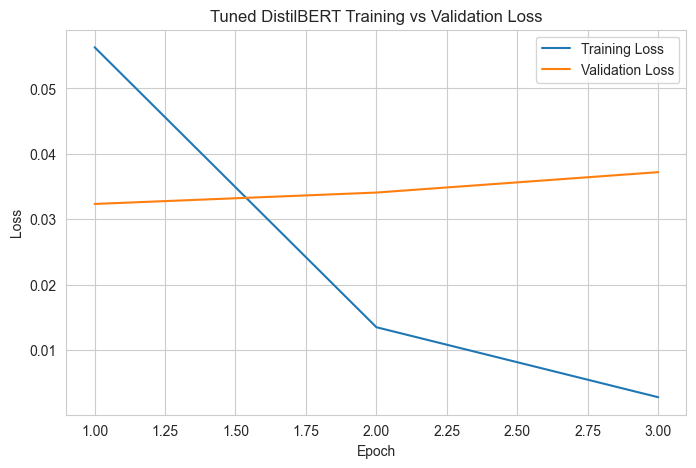

In [26]:
#   Tuned Model  
model_best = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

#   Training Arguments (tuned)  
tuned_args = TrainingArguments(
    output_dir="./distilbert_best",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,               # tuned
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,               # tuned
    weight_decay=0.01,                # tuned
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer_best = Trainer(
    model=model_best,
    args=tuned_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

#   Train Tuned Model  
start = time.time()
trainer_best.train()
end = time.time()
print(f"Tuned training time: {(end-start)/60:.2f} minutes")

#   Evaluate Tuned Model  
best_metrics = trainer_best.evaluate()
print("Tuned model metrics:", best_metrics)

#   Plot Loss Curves  
logs = pd.DataFrame(trainer_best.state.log_history)
train_loss = logs[logs["loss"].notna()][["epoch", "loss"]]
val_loss = logs[logs["eval_loss"].notna()][["epoch", "eval_loss"]]

plt.figure(figsize=(8,5))
plt.plot(train_loss["epoch"], train_loss["loss"], label="Training Loss")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Tuned DistilBERT Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()



# comparison analysis 

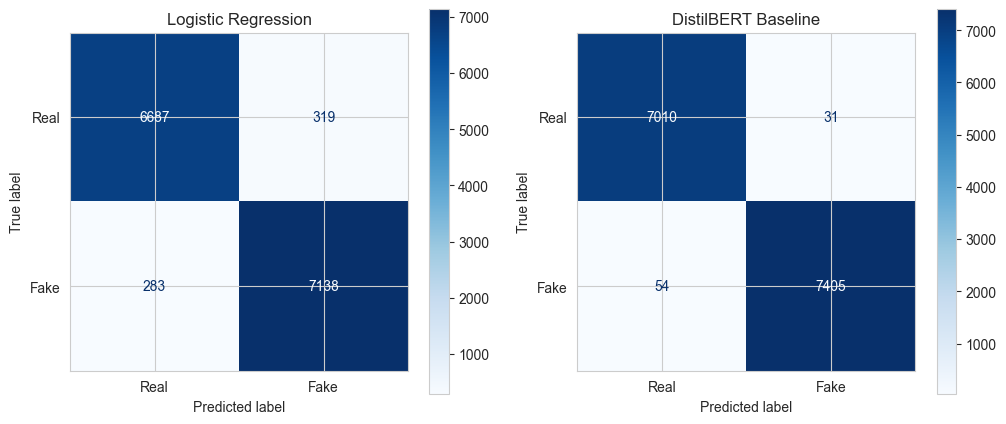

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_estimator(
    model_lr, X_test, y_test,
    display_labels=['Real', 'Fake'],
    cmap='Blues', ax=axes[0], values_format='d'
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_true_baseline, y_pred_baseline,
    display_labels=['Real', 'Fake'], cmap='Blues', ax=axes[1], values_format='d'
)
axes[1].set_title("DistilBERT Baseline")

plt.show()


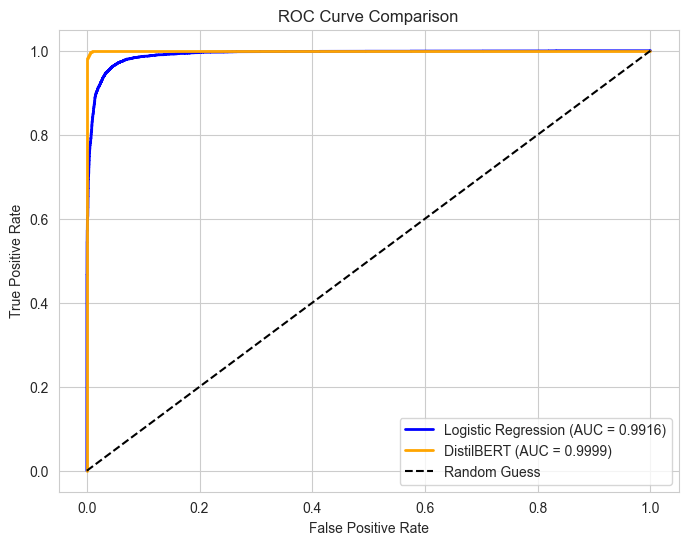

In [88]:
# ROC Curve Comparison 

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# DistilBERT
fpr_bert, tpr_bert, _ = roc_curve(y_true_baseline, y_proba_baseline)
roc_auc_bert = auc(fpr_bert, tpr_bert)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.4f})", color='blue', linewidth=2)
plt.plot(fpr_bert, tpr_bert, label=f"DistilBERT (AUC = {roc_auc_bert:.4f})", color='orange', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


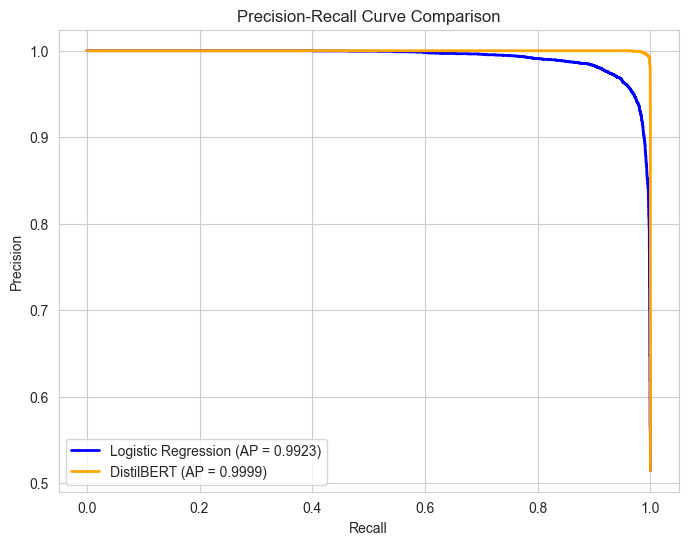

In [89]:

# Precision-Recall Curve Comparison 

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba)
ap_lr = average_precision_score(y_test, y_proba)

# DistilBERT
precision_bert, recall_bert, _ = precision_recall_curve(y_true_baseline, y_proba_baseline)
ap_bert = average_precision_score(y_true_baseline, y_proba_baseline)

plt.figure(figsize=(8,6))
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (AP = {ap_lr:.4f})", color='blue', linewidth=2)
plt.plot(recall_bert, precision_bert, label=f"DistilBERT (AP = {ap_bert:.4f})", color='orange', linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


In [87]:
sample_indices = X_test.sample(10, random_state=42).index
for idx in sample_indices:
    text = X_test.loc[idx, 'full_text']
    actual = y_test.loc[idx]
    lr_pred = model_lr.predict(X_test.loc[[idx]])[0]
    
    # DistilBERT prediction
    encoded = tokenizer([text], truncation=True, padding="max_length", max_length=256, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = distilbert_model(**encoded).logits
        probs = softmax(logits, dim=1).cpu().numpy()[0]
        distilbert_pred = int(probs.argmax())
    
    print(f"Text: {text[:100]}...")
    print(f"Actual: {actual} | LR: {lr_pred} | DistilBERT: {distilbert_pred}")


Text: EU says understands U.S. strikes in Syria but political solution key BRUSSELS (Reuters) - The Europe...
Actual: 0 | LR: 0 | DistilBERT: 0
Text: WIKILEAKS : Hillary Receiving Donations from Radical Muslims in Turkey – TruthFeed WIKILEAKS : Hilla...
Actual: 1 | LR: 1 | DistilBERT: 1
Text: Dyson Wants to Create a Hair Dryer Revolution - The New York Times WILTSHIRE, England  —   Sir James...
Actual: 0 | LR: 0 | DistilBERT: 0
Text:  Fox News Bans Gene Simmons For Life For Harassing Staff Off Camera Gene Simmons, the 68-year-old Ki...
Actual: 1 | LR: 1 | DistilBERT: 1
Text: Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Donald...
Actual: 0 | LR: 0 | DistilBERT: 0
Text: Clinton, Obama pledge unity behind Trump presidency (Reuters) - Republican Donald Trump put aside th...
Actual: 0 | LR: 0 | DistilBERT: 0
Text: White House promises welfare overhaul details early next year WASHINGTON (Reuters) - U.S. President ...
Actual: 0 | LR: 0 | Distil